<a href="https://colab.research.google.com/github/alessiamini04-sudo/nokia-consumer-reviews-analysis/blob/main/Nokia_Consumer_Reviews_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nokia vs iPhone: A Data-Driven Analysis of Consumer Reviews**

This project examines consumer evaluations of Nokia smartphones and selected iPhone competitors using online review data. It builds on a previous psychological case study of Nokia's decline by adding a quantitative, consumer-level perspective.
The analysis focuses on two main questions: how consumer ratings differ across Nokia smartphone families, and how Nokia smartphones compare with selected iPhone models within a comparable review period.
The project combines data cleaning, exploratory data analysis, descriptive statistics and statistical comparison. Online reviews are treated as observational consumer feedback rather than as a representative sample of all smartphone buyers, and they are not used to infer the causes of Nokia's strategic decline.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. **Data Setup and File Verification**

This section prepares the Python environment and verifies that all nine CSV files containing smartphone reviews are available. The files will subsequently be combined into a single dataset for cleaning and exploratory analysis.
The complete dataset contains reviews from nine smartphone brands. The analysis will first explore the full dataset and then focus on Nokia and iPhone to construct a comparable sample for consumer-rating analysis.

In [ ]:
from pathlib import Path

# Permanent data folder stored in Google Drive
DATA_DIR = Path("/content/drive/MyDrive/nokia_project/data")

# Find the nine smartphone review CSV files
csv_files = sorted(DATA_DIR.glob("*.csv"))

print("Data directory:", DATA_DIR)
print("CSV files found:", len(csv_files))

for f in csv_files:
    print("-", f.name)

# Verify that all nine datasets are available
assert len(csv_files) == 9, (
    f"Expected 9 CSV files, but found {len(csv_files)}."
)

Data directory: /content/drive/MyDrive/nokia_project/data
CSV files found: 9
- iphone.csv
- lenova.csv
- micromax.csv
- moto.csv
- nokia.csv
- oppo.csv
- panasonic.csv
- redmi.csv
- vivo.csv


## 2. **Loading and Combining the Review Datasets**

The nine CSV files contain consumer reviews of different smartphone brands. The goal of this section is to combine them into a single dataset that can subsequently be cleaned and explored, with particular attention to Nokia and iPhone.
Because the original files do not contain column headers, column names are assigned manually. Latin-1 encoding is used to read the files consistently, including records containing non-UTF-8 characters.

In [ ]:

# Define column names
COLUMNS = [
    "user_name", "user_id", "product_name", "product_id",
    "rating", "review_title", "review_text",
    "upvotes", "downvotes", "review_date"
]

# Load and combine the nine CSV files
frames = []

for path in csv_files:
    df = pd.read_csv(
        path,
        header=None,
        names=COLUMNS,
        encoding="latin1",
        low_memory=False
    )

    df["brand"] = {
        "lenova": "Lenovo",
        "moto": "Motorola",
        "iphone": "iPhone"
    }.get(path.stem, path.stem.title())

    frames.append(df)

reviews_raw = pd.concat(frames, ignore_index=True)

print("Dataset dimensions:", reviews_raw.shape)

display(
    reviews_raw[
        ["brand", "product_name", "rating", "review_date"]
    ].head()
)


Dataset dimensions: (161192, 11)


,brand,product_name,rating,review_date
0,iPhone,"Apple iPhone 7 Plus (Gold, 32 GB)",5,17-Oct-16
1,iPhone,"Apple iPhone 7 Plus (Gold, 32 GB)",5,12-Oct-16
2,iPhone,"Apple iPhone 7 Plus (Gold, 32 GB)",5,08-Oct-16
3,iPhone,"Apple iPhone 7 Plus (Gold, 32 GB)",5,13-Oct-16
4,iPhone,"Apple iPhone 7 Plus (Gold, 32 GB)",5,22-May-17


**Result and interpretation**

The nine files were successfully combined into a dataset containing 161,192 reviews and 11 variables. Each observation represents an individual consumer review and includes information about the smartphone brand, product, rating and review date.
This combined dataset provides the starting point for the subsequent data-cleaning and exploratory-analysis stages. Before making comparisons between Nokia and iPhone, the data must be checked for missing values, invalid observations, duplicates and differences in review coverage across brands and years.

## 3. **Data Cleaning and Quality Assessment**

Before analysing consumer evaluations, the combined dataset is checked for basic data-quality issues. Review dates and ratings are converted into appropriate data types, and the dataset is examined for missing values, exact duplicate records, invalid dates and ratings outside the expected 1–5 scale.
These checks determine which observations can be retained for the subsequent exploratory and statistical analyses.

In [ ]:

# Create a working copy of the dataset
reviews = reviews_raw.copy()

# Convert dates and numerical variables
reviews["date"] = pd.to_datetime(
    reviews["review_date"],
    format="%d-%b-%y",
    errors="coerce"
)

reviews["year"] = reviews["date"].dt.year

for col in ["rating", "upvotes", "downvotes"]:
    reviews[col] = pd.to_numeric(
        reviews[col],
        errors="coerce"
    )

# Assess missing values
quality = pd.DataFrame({
    "missing_n": reviews.isna().sum(),
    "missing_pct": (
        reviews.isna().mean() * 100
    ).round(2)
})

# Check duplicates, dates and ratings
duplicate_count = reviews.duplicated(
    subset=COLUMNS + ["brand"]
).sum()

invalid_dates = reviews["date"].isna().sum()

invalid_ratings = (
    ~reviews["rating"].between(1, 5)
).sum()

print("Exact duplicates:", duplicate_count)
print("Unparseable dates:", invalid_dates)
print("Ratings outside 1–5:", invalid_ratings)

print("Total missing values:", reviews.isna().sum().sum())


Exact duplicates: 1601
Unparseable dates: 0
Ratings outside 1–5: 0
Total missing values: 0


In [ ]:

# Remove exact duplicate reviews
reviews = reviews.drop_duplicates(
    subset=COLUMNS + ["brand"]
).reset_index(drop=True)

print("Reviews after cleaning:", len(reviews))
print("Duplicates remaining:",
      reviews.duplicated(
          subset=COLUMNS + ["brand"]
      ).sum())
# Final dataset used in the subsequent analyses
reviews_clean = reviews.copy()

print("Final clean dataset:", reviews_clean.shape)

Reviews after cleaning: 159591
Duplicates remaining: 0
Final clean dataset: (159591, 13)


### **Results and Interpretation**

The initial dataset contained 161,192 review records, including 1,601 exact duplicates (0.99%). No missing values, unparseable dates or ratings outside the expected 1–5 scale were detected.
After removing the exact duplicate records, 159,591 review records remained. The resulting dataset contains 13 variables and provides the cleaned data used in the subsequent exploratory analyses.

## 4. **Exploratory Data Analysis: Brand Coverage**

This section examines how review coverage differs across the nine mobile phone brands in the cleaned dataset. For each brand, the number of reviews, average rating, number of product IDs and review-period coverage are summarised.
The purpose of this exploratory step is not to rank brands, but to evaluate whether direct brand-level comparisons are appropriate and to identify differences in sample composition that should be considered in subsequent analyses.

In [ ]:
brand_summary = (
    reviews_clean.groupby('brand').agg(
        reviews=('rating', 'size'),
        avg_rating=('rating', 'mean'),
        first_review=('date', 'min'),
        last_review=('date', 'max'),
        product_ids=('product_id', 'nunique')
    )
    .sort_values('reviews', ascending=False)
)

display(brand_summary.round(2))


,reviews,avg_rating,first_review,last_review,product_ids
brand,,,,,
Motorola,28348,3.88,2011-02-11,2017-11-17,60
Lenovo,26600,3.69,2013-07-30,2017-11-15,64
Micromax,21057,3.67,2011-12-18,2017-11-16,86
Nokia,19198,3.93,2011-08-19,2017-11-16,58
Panasonic,19108,3.54,2014-08-10,2017-11-17,52
Redmi,15058,3.88,2014-07-22,2017-11-16,34
iPhone,12540,4.27,2013-05-21,2017-11-17,62
Oppo,9675,3.91,2014-08-25,2017-11-16,26
Vivo,8007,4.22,2015-11-18,2017-11-15,25


### **Results and Interpretation**

The cleaned dataset contains 159,591 review records across nine mobile phone brands. Nokia accounts for 19,198 reviews, with an average rating of 3.93/5, while the iPhone dataset contains 12,540 reviews, with an average rating of 4.27/5.
These averages are descriptive and should not be interpreted as direct evidence that one brand was evaluated more favourably overall. The brands differ in the number and composition of products represented and, importantly, in their periods of review coverage.
Nokia reviews range from August 2011 to November 2017, whereas iPhone reviews begin in May 2013. Consequently, subsequent comparisons should control for review period and product composition rather than relying exclusively on overall brand-level averages.

## 5. **Temporal Analysis: Nokia vs iPhone**

Nokia and iPhone reviews cover different observation periods, making overall brand-level averages potentially misleading. This section examines review coverage and average ratings over time to assess temporal differences between the two datasets and to identify periods in which subsequent comparisons may be more appropriate.

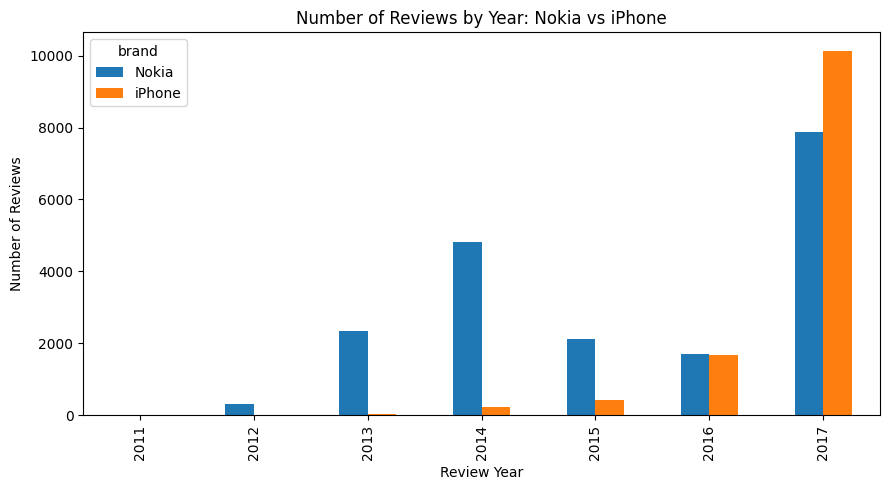

In [ ]:
# Select Nokia and iPhone reviews
comparison = reviews_clean[
    reviews_clean["brand"].isin(["Nokia", "iPhone"])
].copy()

# Count reviews by year and brand
counts = pd.crosstab(
    comparison["year"],
    comparison["brand"]
)

# Plot annual review counts
counts.plot(
    kind="bar",
    figsize=(9, 5),
    title="Number of Reviews by Year: Nokia vs iPhone"
)

plt.ylabel("Number of Reviews")
plt.xlabel("Review Year")
plt.tight_layout()
plt.show()

**Results and Interpretation**

Review coverage differs substantially across years and between the two brands. Nokia reviews are available from 2011, whereas iPhone reviews begin in 2013. Review volume also increases considerably in the later years of the dataset.
These differences indicate that overall brand-level averages combine observations collected during different periods and with very different sample sizes. Subsequent analyses will therefore restrict comparisons to overlapping periods and comparable product groups.

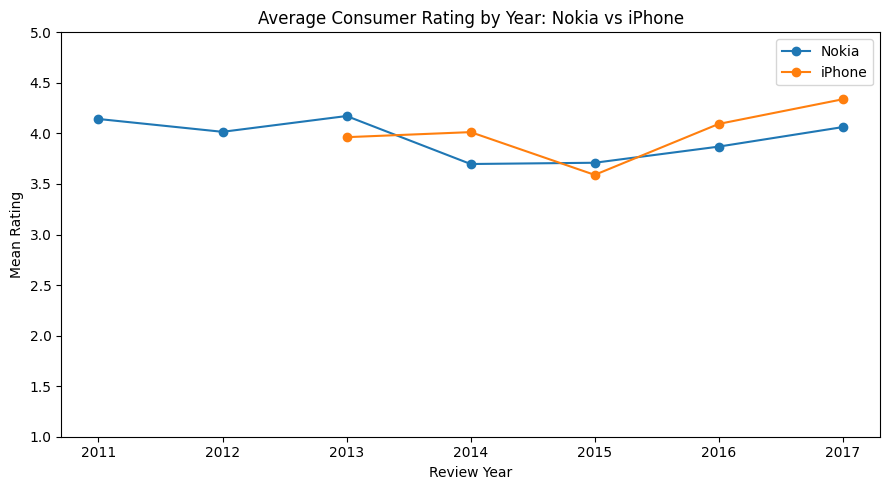

In [ ]:
# Calculate annual mean ratings
year_brand = (
    comparison
    .groupby(["year", "brand"])
    .agg(
        n=("rating", "size"),
        mean_rating=("rating", "mean")
    )
    .reset_index()
)

# Plot mean ratings over time
fig, ax = plt.subplots(figsize=(9, 5))

for brand, data in year_brand.groupby("brand"):
    ax.plot(
        data["year"],
        data["mean_rating"],
        marker="o",
        label=brand
    )

ax.set_title("Average Consumer Rating by Year: Nokia vs iPhone")
ax.set_xlabel("Review Year")
ax.set_ylabel("Mean Rating")
ax.set_ylim(1, 5)
ax.legend()

plt.tight_layout()
plt.show()

**Results and Interpretation**

Average ratings also vary over time for both brands. The relative difference between Nokia and iPhone is therefore not stable across the observation period.
This reinforces the need to avoid interpreting the overall brand averages as direct measures of relative consumer satisfaction. Differences may reflect not only brand evaluations but also changes in the products represented and in the composition of reviews across years.
A more meaningful comparison therefore requires both a common review period and a clearer definition of the Nokia product groups included in the analysis.

## 6. **Selecting Comparable Nokia Smartphones**
The Nokia dataset contains a heterogeneous range of mobile phones, including smartphone families such as Lumia and Nokia X as well as feature-phone models. Since iPhones are smartphones, comparing the complete Nokia dataset with iPhone would combine different product categories. We therefore inspect Nokia's product composition before defining the smartphone families used in the subsequent comparison.

In [ ]:
# Examine the Nokia products represented in the dataset
nokia = reviews_clean[
    reviews_clean["brand"].eq("Nokia")
].copy()

nokia_products = (
    nokia
    .groupby("product_name")
    .agg(
        reviews=("rating", "size"),
        mean_rating=("rating", "mean")
    )
    .sort_values("reviews", ascending=False)
)

print("Nokia reviews:", len(nokia))
print("Distinct product names:", nokia["product_name"].nunique())

display(nokia_products.head(10).round(2))

Nokia reviews: 19198
Distinct product names: 42


,reviews,mean_rating
product_name,,
Nokia 150,1345,4.15
Nokia 105,1270,3.87
Nokia 220,1209,3.79
Nokia 130,1088,3.95
Nokia 108 Dual SIM,927,4.08
Nokia 215,877,4.04
Nokia 230 Dual SIM,820,4.14
Nokia 225,745,3.80
Nokia 130 DS,630,4.01


**Product Composition**

The Nokia dataset contains a heterogeneous set of products rather than a single comparable smartphone category. Among the most frequently reviewed products are several Nokia feature-phone models, while the dataset also contains smartphone families such as Lumia and Nokia X.
Because the objective of the project is to compare consumer evaluations of smartphones, the complete Nokia sample is not directly comparable with the iPhone sample. The next step therefore identifies and separates the Nokia smartphone families that are relevant for the analysis.

## 7. **Identifying Nokia Smartphone Families**

To create a more comparable smartphone sample, Nokia products are classified using their product names. Devices containing “Lumia” are identified as Lumia smartphones, while Nokia X, X2 and XL devices are grouped into the Nokia X family. All remaining Nokia products are retained as “Other Nokia” and excluded from the subsequent smartphone comparison.

In [ ]:

# Classify Nokia products into the smartphone families used in the analysis

nokia = reviews_clean[
    reviews_clean["brand"].eq("Nokia")
].copy()

def classify_nokia(name):
    name = str(name).lower().strip()

    if "lumia" in name:
        return "Nokia Lumia"

    elif name.startswith(("nokia x ", "nokia x2 ", "nokia xl ")):
        return "Nokia X"

    else:
        return "Other Nokia"

nokia["category"] = nokia["product_name"].apply(classify_nokia)

category_summary = (
    nokia
    .groupby("category")
    .agg(
        reviews=("rating", "size"),
        product_ids=("product_id", "nunique")
    )
    .sort_values("reviews", ascending=False)
)

display(category_summary)

print("Total Nokia reviews:", len(nokia))
print("Total Nokia product IDs:", nokia["product_id"].nunique())



,reviews,product_ids
category,,
Other Nokia,11168,36
Nokia Lumia,4890,14
Nokia X,3140,8


Total Nokia reviews: 19198
Total Nokia product IDs: 58


**Results and Interpretation**

The Nokia dataset contains 19,198 reviews across 58 product IDs. Of these, 4,890 reviews refer to Lumia smartphones and 3,140 to Nokia X smartphones. The remaining 11,168 reviews correspond to other Nokia products.
Since the objective is to compare smartphone consumer evaluations, the subsequent analysis focuses on the Lumia and Nokia X families rather than on the complete Nokia sample. This avoids combining substantially different Nokia product categories in the comparison with iPhone.

8. **Smartphone-only Comparison: Selecting a Comparable Year**





After isolating the two Nokia smartphone families, review coverage is examined across years to identify a period in which Nokia Lumia, Nokia X and iPhone can be compared under similar temporal conditions. This step avoids comparing overall ratings based on substantially different observation periods and sample sizes.

In [ ]:
# Check yearly review coverage for the three smartphone groups

lumia_all = nokia[
    nokia["category"] == "Nokia Lumia"
].copy()

nokia_x_all = nokia[
    nokia["category"] == "Nokia X"
].copy()

iphone_all = reviews_clean[
    reviews_clean["brand"] == "iPhone"
].copy()

coverage = pd.concat([
    lumia_all.assign(group="Nokia Lumia"),
    nokia_x_all.assign(group="Nokia X"),
    iphone_all.assign(group="iPhone")
])

coverage_table = pd.crosstab(
    coverage["year"],
    coverage["group"]
)

display(coverage_table)

group,Nokia Lumia,Nokia X,iPhone
year,,,
2012,120,0,0
2013,1944,0,54
2014,2052,1635,231
2015,428,428,439
2016,87,232,1679
2017,259,845,10137


**Year selection:**
 Review coverage differs substantially across years. In 2015, the three smartphone groups have very similar sample sizes: 428 Nokia Lumia reviews, 428 Nokia X reviews and 439 iPhone reviews. For this reason, 2015 is selected as the common observation period for the subsequent comparison. This does not make the samples representative of all smartphone consumers, but it reduces the strong temporal and sample-size imbalance observed in other years.

8.1 **Comparison in 2015**

In [ ]:
# Restrict smartphone comparison to 2015

analysis_year = 2015

lumia = nokia[
    (nokia["category"] == "Nokia Lumia") &
    (nokia["year"] == analysis_year)
].copy()

nokia_x = nokia[
    (nokia["category"] == "Nokia X") &
    (nokia["year"] == analysis_year)
].copy()

iphone = reviews_clean[
    (reviews_clean["brand"] == "iPhone") &
    (reviews_clean["year"] == analysis_year)
].copy()

smartphone_summary = pd.DataFrame({
    "Reviews": [
        len(lumia),
        len(nokia_x),
        len(iphone)
    ],
    "Mean rating": [
        lumia["rating"].mean(),
        nokia_x["rating"].mean(),
        iphone["rating"].mean()
    ],
    "Median rating": [
        lumia["rating"].median(),
        nokia_x["rating"].median(),
        iphone["rating"].median()
    ]
}, index=["Nokia Lumia", "Nokia X", "iPhone"])

display(smartphone_summary.round(3))

,Reviews,Mean rating,Median rating
Nokia Lumia,428,3.724,4.0
Nokia X,428,3.701,4.0
iPhone,439,3.590,5.0


**Results and Interpretation**

The 2015 comparison sample contains 1,295 reviews: 428 for Nokia Lumia, 428 for Nokia X and 439 for iPhone. Mean ratings are relatively similar across the three groups: 3.724 for Nokia Lumia, 3.701 for Nokia X and 3.590 for iPhone. Median ratings are 4 for both Nokia groups and 5 for iPhone.
At this stage, these differences are descriptive only. A statistical comparison is required before assessing whether the observed variation in ratings provides evidence of systematic differences between the three groups.

9. **Final Comparable Sample**

Based on the review coverage examined above, the final comparison sample is restricted to 2015 and includes Nokia Lumia, Nokia X and iPhone reviews. These observations are combined into a single dataset that will be used in the subsequent statistical analyses.


In [ ]:

# Create the final comparable sample for 2015

study_sample = pd.concat([
    lumia.assign(group="Nokia Lumia"),
    nokia_x.assign(group="Nokia X"),
    iphone.assign(group="iPhone")
], ignore_index=True)

print("Total reviews in final sample:", len(study_sample))

display(
    study_sample["group"]
    .value_counts()
    .rename("reviews")
)

Total reviews in final sample: 1295


,reviews
group,
iPhone,439
Nokia Lumia,428
Nokia X,428


10. **Statistical comparison of smartphone ratings in 2015**

The final comparable sample contains 1,295 reviews from 2015: 428 Nokia Lumia, 428 Nokia X and 439 iPhone reviews. This section compares the distribution of consumer ratings across the three smartphone groups. Because ratings are measured on an ordinal 1–5 scale, the Kruskal–Wallis test is used to assess whether the rating distributions differ significantly across groups.

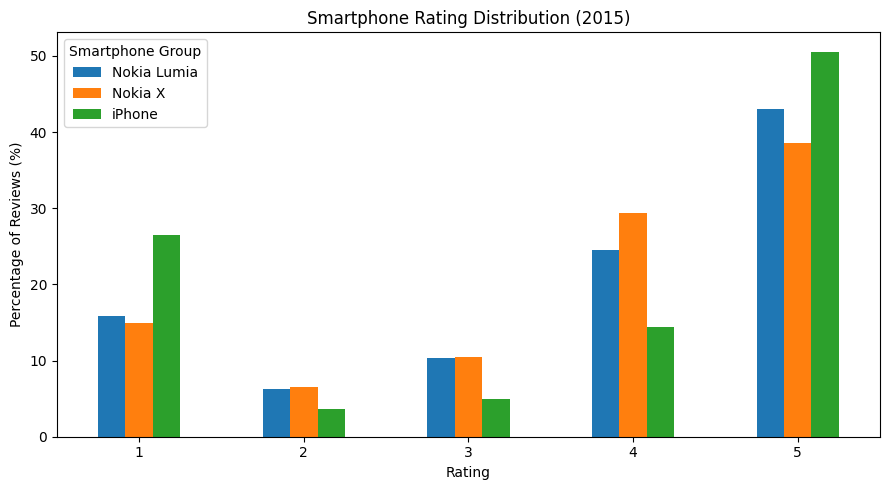

Kruskal-Wallis H = 0.757
p-value = 0.685


In [ ]:
from scipy.stats import kruskal
import matplotlib.pyplot as plt

groups = ["Nokia Lumia", "Nokia X", "iPhone"]

# Rating distribution (%)
rating_dist = (
    pd.crosstab(
        study_sample["rating"],
        study_sample["group"],
        normalize="columns"
    )
    .reindex(columns=groups)
    .mul(100)
)

ax = rating_dist.plot.bar(figsize=(9, 5), rot=0)

ax.set(
    title="Smartphone Rating Distribution (2015)",
    xlabel="Rating",
    ylabel="Percentage of Reviews (%)"
)

ax.legend(title="Smartphone Group")

plt.tight_layout()
plt.show()

# Kruskal-Wallis test
samples = [
    study_sample.loc[
        study_sample["group"] == group,
        "rating"
    ]
    for group in groups
]

h_stat, p_value = kruskal(*samples)

print(f"Kruskal-Wallis H = {h_stat:.3f}")
print(f"p-value = {p_value:.3f}")


**Results and Interpretation**

Results and Interpretation
The three smartphone groups show different descriptive rating patterns. In particular, iPhone reviews appear more polarized, with a relatively larger proportion of both one-star and five-star ratings, while Nokia Lumia and Nokia X reviews are more concentrated around four and five stars.  
However, the Kruskal–Wallis test did not identify a statistically significant difference in rating distributions across the three groups (H = 0.757, p = 0.685). Therefore, within the balanced 2015 sample, the observed differences in rating patterns are descriptive and do not provide sufficient evidence of an overall difference in consumer evaluations across Nokia Lumia, Nokia X and iPhone.

11. **Model-Level Composition of the 2015 Sample**

Product names may distinguish colour, storage or configuration variants of the same underlying smartphone model. To avoid treating these variants as separate devices, product names are consolidated into model families before examining the composition of the 2015 sample.

In [ ]:

# Group color and storage variants
# into the same model family.

import re

def model_family(name):
    name = str(name).lower()

    if 'lumia' in name:
        match = re.search(r'lumia\s+(\d+)', name)
        return f"Lumia {match.group(1)}" if match else "Other Lumia"

    if 'nokia x2' in name:
        return "Nokia X2"
    if 'nokia xl' in name:
        return "Nokia XL"
    if 'nokia x ' in name or name.endswith('nokia x'):
        return "Nokia X"

    if 'iphone 6s plus' in name:
        return "iPhone 6s Plus"
    if 'iphone 6 plus' in name:
        return "iPhone 6 Plus"
    if 'iphone 6s' in name:
        return "iPhone 6s"
    if 'iphone 6' in name:
        return "iPhone 6"
    if 'iphone 5s' in name:
        return "iPhone 5s"
    if 'iphone 5' in name:
        return "iPhone 5"
    if 'iphone 4s' in name:
        return "iPhone 4s"

    return "To verify"

sample_2015 = study_sample.copy()
sample_2015['model_family'] = (
    sample_2015['product_name'].apply(model_family)
)

family_summary = (
    sample_2015
    .groupby(['group', 'model_family'])
    .agg(
        reviews=('rating', 'size'),
        mean_rating=('rating', 'mean'),
        median_rating=('rating', 'median')
    )
    .reset_index()
    .sort_values(['group', 'reviews'], ascending=[True, False])
)

display(family_summary.round(3))


,group,model_family,reviews,mean_rating,median_rating
5,Nokia Lumia,Lumia 630,313,3.792,4.0
2,Nokia Lumia,Lumia 530,66,3.545,4.0
1,Nokia Lumia,Lumia 520,16,3.625,4.0
4,Nokia Lumia,Lumia 625,14,3.143,4.0
3,Nokia Lumia,Lumia 620,11,3.545,4.0
6,Nokia Lumia,Lumia 920,6,5.000,5.0
0,Nokia Lumia,Lumia 510,2,1.000,1.0
8,Nokia X,Nokia X2,270,4.141,4.0
7,Nokia X,Nokia X,112,2.991,3.0
9,Nokia X,Nokia XL,46,2.848,3.5


### **Results and Interpretation**

After consolidating colour, storage and configuration variants, the 2015 sample contains 7 Lumia model families, 3 Nokia X model families and 7 iPhone model families.  
Review coverage is concentrated around a limited number of devices. The Lumia 630 accounts for 313 of 428 Lumia reviews (73%), the Nokia X2 for 270 of 428 Nokia X reviews (63%), and the iPhone 4s for 228 of 439 iPhone reviews (52%).  
Therefore, the group-level comparisons partly reflect the most frequently represented models and should be interpreted as comparisons of the observed 2015 product mix rather than of the entire Nokia or iPhone smartphone portfolios.

12. **Model-Level Comparison of Smartphone Ratings in 2015**

Group-level averages may conceal differences between individual smartphone models. To examine this heterogeneity, the analysis compares average ratings across model families in the 2015 sample. Only model families with at least 30 reviews are included to avoid drawing conclusions from very small samples.

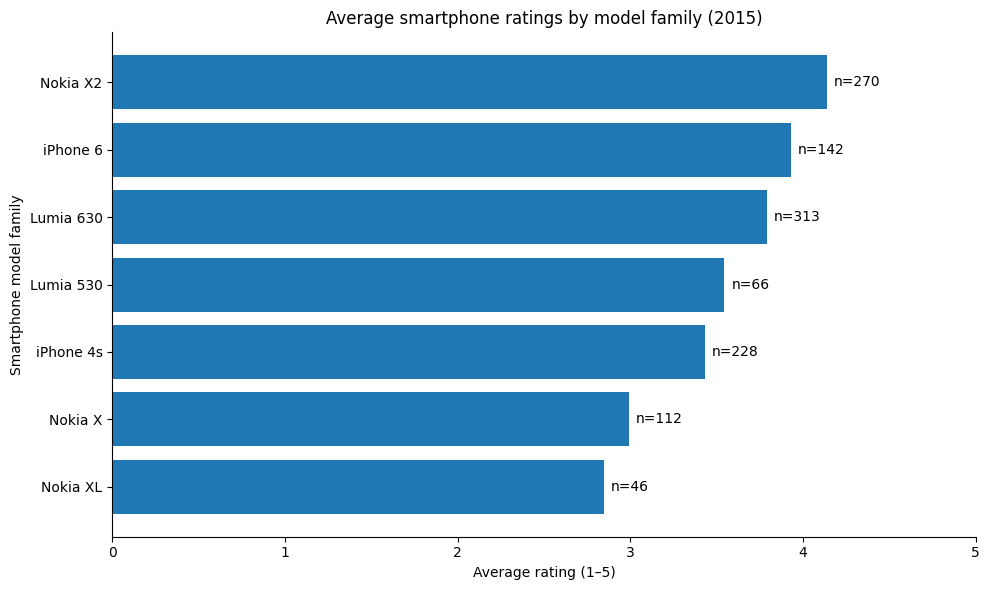

In [ ]:

import matplotlib.pyplot as plt

# Keep only model families with at least 30 reviews
plot_data = (
    family_summary[family_summary['reviews'] >= 30]
    .sort_values('mean_rating')
    .copy()
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_data['model_family'],
    plot_data['mean_rating']
)

# Display the number of reviews next to each bar
for bar, n in zip(bars, plot_data['reviews']):
    ax.text(
        bar.get_width() + 0.04,
        bar.get_y() + bar.get_height() / 2,
        f'n={n}',
        va='center'
    )

ax.set_xlim(0, 5)
ax.set_xlabel('Average rating (1–5)')
ax.set_ylabel('Smartphone model family')
ax.set_title(
    'Average smartphone ratings by model family (2015)'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


**Results and Interpretation**

Among model families with at least 30 reviews, consumer ratings vary substantially within the same smartphone group. Nokia X2 received the highest average rating in the observed 2015 sample, whereas Nokia X and Nokia XL received considerably lower average ratings. Lumia 630 and iPhone 6 also received relatively high evaluations.  
These results show that group-level averages can conceal substantial differences between individual product families. Therefore, the comparison between Nokia Lumia, Nokia X and iPhone should be interpreted alongside the composition of the specific models represented in the 2015 sample. The results are descriptive and do not establish that one model is generally superior to another.

13 **Check for Repeated Reviewers and Group Overlap**

In [ ]:
# Check repeated reviewers in the final 2015 sample

print("Number of reviews:", len(study_sample))
print("Unique users:", study_sample["user_id"].nunique())

# Number of reviews contributed by each user
user_review_counts = study_sample.groupby("user_id").size()

multiple_review_users = user_review_counts[user_review_counts > 1]

print(
    "Users with more than one review:",
    len(multiple_review_users)
)

print(
    "Percentage of users with multiple reviews:",
    round(len(multiple_review_users) /
          study_sample["user_id"].nunique() * 100, 2),
    "%"
)

print(
    "Maximum reviews contributed by one user:",
    user_review_counts.max()
)

# Check whether the same user reviewed the same product more than once
repeated_user_product = (
    study_sample
    .groupby(["user_id", "product_id"])
    .size()
)

print(
    "Repeated user-product pairs:",
    (repeated_user_product > 1).sum()
)

# Check whether the same user appears in more than one smartphone group
groups_per_user = (
    study_sample
    .groupby("user_id")["group"]
    .nunique()
)

multi_group_users = (groups_per_user > 1).sum()

print("\nUSER OVERLAP ACROSS GROUPS")
print("Users appearing in more than one group:", multi_group_users)



Number of reviews: 1295
Unique users: 864
Users with more than one review: 281
Percentage of users with multiple reviews: 32.52 %
Maximum reviews contributed by one user: 3
Repeated user-product pairs: 0

USER OVERLAP ACROSS GROUPS
Users appearing in more than one group: 0


**Results and Interpretation**

The 2015 analytical sample contains 1,295 reviews from 864 unique users. A total of 281 users contributed more than one review, although no user reviewed the same product more than once. In addition, no user appears in more than one smartphone group. Because some users contribute multiple observations within the same group, a subsequent user-level analysis is used as a robustness check.

14 **Robustness check: user-level comparison**

Because some users submitted multiple reviews within the same smartphone group, the review-level analysis may give greater weight to those users. As a robustness check, reviews are therefore aggregated at the user level so that each reviewer contributes a single observation.



In [ ]:
# STEP 14 — User-level robustness check

from scipy.stats import kruskal

# Use the final 2015 comparison sample
comparison_2015 = study_sample.copy()

# Aggregate reviews at the user level
# One observation per user
user_level = (
    comparison_2015
    .groupby(["group", "user_id"], as_index=False)
    .agg(
        mean_rating=("rating", "mean"),
        n_reviews=("rating", "size")
    )
)
print("USER-LEVEL SAMPLE")
print("Number of users:", len(user_level))


# --------------------------------------------------
# Descriptive statistics
# --------------------------------------------------

user_summary = (
    user_level
    .groupby("group")["mean_rating"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
)

display(user_summary)


# --------------------------------------------------
# Kruskal-Wallis test at user level
# --------------------------------------------------

group_order = [
    "Nokia Lumia",
    "Nokia X",
    "iPhone"
]

samples_user = [
    user_level.loc[
        user_level["group"] == group,
        "mean_rating"
    ].dropna()
    for group in group_order
]

H_user, p_user = kruskal(*samples_user)

print("\nUSER-LEVEL KRUSKAL-WALLIS TEST")
print(f"H = {H_user:.3f}")
print(f"p-value = {p_user:.6f}")


# --------------------------------------------------
# Sample sizes
# --------------------------------------------------

print("\nUSERS ANALYSED BY GROUP")

for group, sample in zip(group_order, samples_user):
    print(f"{group}: {len(sample)} users")

USER-LEVEL SAMPLE
Number of users: 864


,count,mean,median,std
group,,,,
Nokia Lumia,238,3.630,4.0,1.475
Nokia X,187,3.722,4.0,1.425
iPhone,439,3.590,5.0,1.708



USER-LEVEL KRUSKAL-WALLIS TEST
H = 0.998
p-value = 0.607151

USERS ANALYSED BY GROUP
Nokia Lumia: 238 users
Nokia X: 187 users
iPhone: 439 users


**Results and Interpretation**

The user-level robustness analysis included 864 unique reviewers: 238 Nokia Lumia users, 187 Nokia X users and 439 iPhone users. After averaging multiple reviews submitted by the same user, mean ratings were 3.630 for Nokia Lumia, 3.722 for Nokia X and 3.590 for iPhone. The Kruskal–Wallis test did not indicate a statistically significant difference between the three groups (H = 0.998, p = 0.607). This is consistent with the review-level analysis (H = 0.757, p = 0.685), indicating that the overall conclusion remains unchanged when each reviewer contributes only one observation. Because no users appeared in more than one smartphone group, the groups also remained independent at the reviewer level.

15  **Bootstrap confidence intervals at the user level**

In [ ]:
# STEP 15 — Bootstrap confidence intervals at the user level

import numpy as np
import pandas as pd

# Reproducible random generator
rng = np.random.default_rng(42)

# Number of bootstrap samples
n_boot = 2000

group_order = [
    'Nokia Lumia',
    'Nokia X',
    'iPhone'
]

bootstrap_results = []

for group in group_order:

    # One observation per user, already created in Step 19.7
    values = (
        user_level.loc[
            user_level['group'] == group,
            'mean_rating'
        ]
        .dropna()
        .to_numpy()
    )

    n_users = len(values)

    bootstrap_means = np.empty(n_boot)

    # Resample users with replacement
    for i in range(n_boot):
        sampled_users = rng.choice(
            values,
            size=n_users,
            replace=True
        )

        bootstrap_means[i] = sampled_users.mean()

    # 95% percentile bootstrap confidence interval
    ci_lower, ci_upper = np.percentile(
        bootstrap_means,
        [2.5, 97.5]
    )

    bootstrap_results.append({
        'group': group,
        'n_users': n_users,
        'mean_rating': values.mean(),
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    })


bootstrap_results = pd.DataFrame(bootstrap_results)

display(
    bootstrap_results.round(3)
)


,group,n_users,mean_rating,ci_lower,ci_upper
0,Nokia Lumia,238,3.630,3.450,3.815
1,Nokia X,187,3.722,3.508,3.920
2,iPhone,439,3.590,3.431,3.745


**Interpretation**

The user-level bootstrap analysis produced similar mean ratings across the three smartphone groups. Nokia X showed the highest estimated mean rating (3.722, 95% bootstrap CI [3.508, 3.920]), followed by Nokia Lumia (3.630, 95% CI [3.450, 3.815]) and iPhone (3.590, 95% CI [3.431, 3.745]).

The confidence intervals overlap substantially, indicating considerable uncertainty around the observed differences in mean ratings. This pattern is consistent with the user-level Kruskal–Wallis test, which did not detect statistically significant differences among the three groups.

Together, these robustness checks suggest that the main conclusion is not driven by users who contributed multiple reviews. When each reviewer is given equal weight, differences in consumer ratings across Nokia Lumia, Nokia X and iPhone remain limited in the 2015 comparison sample.

**16. Visualization of User-Level Bootstrap Confidence Intervals**


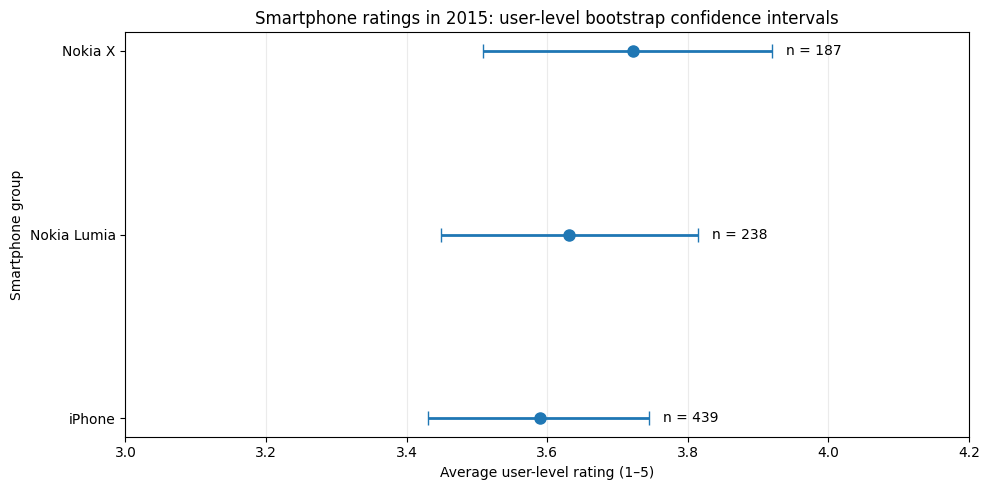

In [ ]:

# STEP 16 — Visualization of User-Level Bootstrap Confidence Intervals

import matplotlib.pyplot as plt

plot_data = bootstrap_results.sort_values(
    'mean_rating'
).copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.errorbar(
    x=plot_data['mean_rating'],
    y=plot_data['group'],
    xerr=[
        plot_data['mean_rating'] - plot_data['ci_lower'],
        plot_data['ci_upper'] - plot_data['mean_rating']
    ],
    fmt='o',
    markersize=8,
    capsize=5,
    linewidth=2
)

ax.set_xlim(3.0, 4.2)
ax.set_xlabel('Average user-level rating (1–5)')
ax.set_ylabel('Smartphone group')

ax.set_title(
    'Smartphone ratings in 2015: '
    'user-level bootstrap confidence intervals'
)

ax.grid(axis='x', alpha=0.25)

for i, row in enumerate(plot_data.itertuples()):
    ax.annotate(
        f'n = {row.n_users}',
        (row.ci_upper, i),
        xytext=(10, 0),
        textcoords='offset points',
        va='center'
    )

plt.tight_layout()

# Save the figure for the final report
plt.savefig(
    'bootstrap_ratings_2015.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


### Interpretation

The user-level bootstrap estimates show relatively similar average ratings across the three smartphone groups. Nokia X had the highest estimated mean rating, followed by Nokia Lumia and iPhone. However, the 95% bootstrap confidence intervals overlap substantially across the three groups, indicating considerable uncertainty around the observed differences.  
This pattern is consistent with the user-level Kruskal–Wallis test, which did not identify statistically significant differences between the groups. Therefore, the observed differences in average ratings should be interpreted cautiously and should not be considered evidence of clear differences in consumer evaluations.

## 17. **Discussion:**

The analysis provides a consumer-level perspective on Nokia smartphone evaluations during the later stage of the smartphone market transition. After restricting the comparison to smartphones and selecting 2015 as the most balanced observation year, the results did not show statistically significant differences in overall ratings between Nokia Lumia, Nokia X and iPhone.
Although the descriptive mean ratings differed slightly across the three groups, the review-level Kruskal–Wallis test did not identify significant differences. This result remained consistent when the analysis was repeated at the user level, giving each reviewer equal weight. The bootstrap confidence intervals also overlapped substantially, reinforcing the conclusion that the observed differences in average ratings are uncertain and should not be interpreted as clear evidence that one smartphone group was evaluated more positively than another.
At the same time, the model-level analysis revealed considerable variation within Nokia itself. Some Nokia models, such as the Nokia X2 and Lumia 630, received relatively high average ratings, while other models such as Nokia X and Nokia XL were evaluated less favourably. This suggests that brand-level averages can hide meaningful differences between individual product families.
These findings complement the original psychological case study of Nokia's decline. The earlier case study focused on organisational decision-making, cognitive biases and strategic adaptation, whereas the present analysis examines observable consumer evaluations. The review data cannot determine whether Nokia's strategic decisions or cognitive biases caused its market decline, but they show that **Nokia's difficulties cannot be reduced to uniformly negative consumer evaluations of its smartphones**.




## 18. **Limitations**

The findings should be interpreted in light of several limitations.

First, the dataset consists of online consumer reviews and therefore does not represent a random or representative sample of all smartphone users. Individuals who choose to post reviews may differ from consumers who do not leave online feedback.

Second, the main comparison was restricted to 2015 because this was the year with the most balanced review coverage across Nokia Lumia, Nokia X and iPhone. Consequently, the analysis does not directly examine Nokia's initial response to the smartphone transition following the introduction of the iPhone in 2007.

Third, the 2015 sample is concentrated around a limited number of smartphone models. For example, Lumia 630, Nokia X2 and iPhone 4s account for a substantial proportion of the reviews within their respective groups. Therefore, the results reflect the specific product mix represented in the dataset rather than the complete Nokia or iPhone smartphone portfolios.
Finally, some users contributed more than one review. Although the user-level robustness analysis produced results consistent with the review-level analysis, repeated observations were present within groups and should be considered when interpreting the findings

19. **Conclusion**

This project used Python-based data cleaning, exploratory analysis and statistical testing to examine consumer evaluations of Nokia smartphones and selected iPhone models.
The analysis showed that consumer ratings varied substantially across Nokia product families, suggesting that Nokia should not be treated as a homogeneous smartphone category. In the balanced 2015 comparison, however, no statistically significant differences were found in overall ratings between Nokia Lumia, Nokia X and iPhone. This result remained consistent when the analysis was repeated at the user level and was further supported by overlapping bootstrap confidence intervals.
The findings therefore suggest that Nokia's strategic difficulties during the smartphone transition cannot be explained simply by uniformly negative consumer evaluations of its smartphones. Instead, the data reveal substantial variation between individual Nokia product families and illustrate how consumer-level evidence can complement the psychological and organisational perspective developed in the original case study.